In [104]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, MobileNetV2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input

In [105]:
from tensorflow.keras.datasets import cifar100
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')
(X_train_coarse, y_train_coarse), (X_test_coarse, y_test_coarse) = cifar100.load_data(label_mode='coarse')

In [106]:
fine_labels = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 
    'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 
    'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 
    'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 
    'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 
    'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 
    'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

coarse_labels = ['aquatic_mammals', 'fish', 'flowers', 'food_containers', 'fruit_and_vegetables',
    'household_electrical_devices', 'household_furniture', 'insects', 'large_carnivores',
    'large_man-made_outdoor_things', 'large_natural_outdoor_scenes', 
    'large_omnivores_and_herbivores', 'medium_mammals', 'non-insect_invertebrates',
    'people', 'reptiles', 'small_mammals', 'trees', 'vehicles_1', 'vehicles_2']

1. Normalisation

In [107]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_coarse = X_train_coarse / 255.0
X_test_coarse = X_test_coarse / 255.0

2. One-hot encoding

In [108]:
y_train_fine = to_categorical(y_train, 100)  
y_test_fine = to_categorical(y_test, 100)


y_train_coarse = to_categorical(y_train_coarse, 20)  

Split

In [109]:
X_train, X_val, y_train_fine, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

3. Data augmentation (CRITIQUE pour 600 images/classe)
   - Rotation: ±20 degrés
   - Zoom: ±25%
   - Shift: ±15%
   - Flip horizontal: activé
   - Brightness: ±20%
   - Cutout/Random Erasing (optionnel mais recommandé)
   - Mixup (optionnel avancé)

In [110]:
data_augmentation = keras.Sequential([
    layers.Resizing(224, 224),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0))  # 🔥 FIX
])

In [111]:


inputs = keras.Input(shape=(32,32,3))
x = data_augmentation(inputs)
x = preprocess_input(x)

In [112]:
# Récupère un batch pour tester
image = X_train[0]

# Afficher la forme de l'image
print("Shape de l'image :", image.shape)

Shape de l'image : (32, 32, 3)


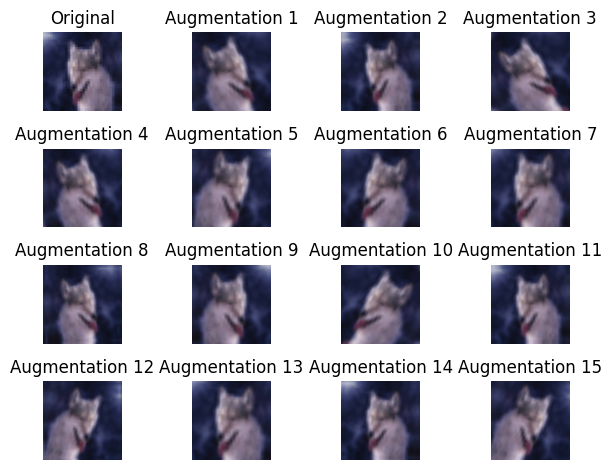

In [113]:
# Afficher l'image originale
plt.subplot(4,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Générer 15 augmentations
for i in range(15):
    augmented_img = data_augmentation(tf.expand_dims(image, 0), training=True)  # ajouter batch dim
    plt.subplot(4,4,i+2)
    plt.imshow(tf.squeeze(augmented_img))  # retirer la dimension batch
    plt.title(f"Augmentation {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **CallBack**

In [114]:
callback_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath="models/best_model_demo.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

**Architecture 1 : CNN Personnalisé Simple**

In [115]:
cnn_model = keras.Sequential([
    layers.Conv2D(64, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')  # 100 classes!
])

In [116]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history_with_callback = cnn_model.fit(
    X_train, y_train_fine,
    batch_size=64,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    verbose=1
)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0265 - loss: 4.7339
Epoch 1: val_accuracy improved from None to 0.04520, saving model to models/best_model_demo.h5



Epoch 1: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.0344 - loss: 4.4542 - val_accuracy: 0.0452 - val_loss: 4.2938 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0520 - loss: 4.2106
Epoch 2: val_accuracy improved from 0.04520 to 0.09730, saving model to models/best_model_demo.h5



Epoch 2: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.0575 - loss: 4.1787 - val_accuracy: 0.0973 - val_loss: 3.9334 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0717 - loss: 4.0420
Epoch 3: val_accuracy improved from 0.09730 to 0.13160, saving model to models/best_model_demo.h5



Epoch 3: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.0763 - loss: 4.0146 - val_accuracy: 0.1316 - val_loss: 3.7062 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0926 - loss: 3.9070
Epoch 4: val_accuracy improved from 0.13160 to 0.15890, saving model to models/best_model_demo.h5



Epoch 4: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.0942 - loss: 3.8863 - val_accuracy: 0.1589 - val_loss: 3.5134 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1074 - loss: 3.7770
Epoch 5: val_accuracy did not improve from 0.15890
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.1104 - loss: 3.7675 - val_accuracy: 0.1457 - val_loss: 3.6718 - learning_rate: 0.0010
Epoch 6/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1256 - loss: 3.6682
Epoch 6: val_accuracy improved from 0.15890 to 0.19180, saving model to models/best_model_demo.h5



Epoch 6: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.1299 - loss: 3.6511 - val_accuracy: 0.1918 - val_loss: 3.3043 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1453 - loss: 3.5548
Epoch 7: val_accuracy improved from 0.19180 to 0.23400, saving model to models/best_model_demo.h5



Epoch 7: finished saving model to models/best_model_demo.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.1515 - loss: 3.5392 - val_accuracy: 0.2340 - val_loss: 3.2007 - learning_rate: 0.0010
Epoch 8/100
114/625 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.1573 - loss: 3.4474

KeyboardInterrupt: 

**Architecture 3 : Transfer Learning - MobileNetV2**

In [ ]:
base_mobilenet_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_mobilenet_model.trainable = False

mobilenet_model = keras.Sequential([
    layers.Resizing(224, 224),
    layers.Lambda(preprocess_input),
    base_mobilenet_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])



In [ ]:
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_history_with_callback = mobilenet_model.fit(
    X_train, y_train_fine,
    batch_size=64,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.2110 - loss: 3.4581
Epoch 1: val_accuracy improved from 0.32210 to 0.49480, saving model to models/best_model_demo.h5



Epoch 1: finished saving model to models/best_model_demo.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 244s 773ms/step - accuracy: 0.3090 - loss: 2.8157 - val_accuracy: 0.4948 - val_loss: 1.8900 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.4548 - loss: 2.0620
Epoch 2: val_accuracy improved from 0.49480 to 0.52860, saving model to models/best_model_demo.h5



Epoch 2: finished saving model to models/best_model_demo.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 248s 792ms/step - accuracy: 0.4624 - loss: 2.0270 - val_accuracy: 0.5286 - val_loss: 1.6976 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.4976 - loss: 1.8355
Epoch 3: val_accuracy improved from 0.52860 to 0.54590, saving model to models/best_model_demo.h5



Epoch 3: finished saving model to models/best_model_demo.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 245s 784ms/step - accuracy: 0.5021 - loss: 1.8213 - val_accuracy: 0.5459 - val_loss: 1.6442 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.5324 - loss: 1.6941
Epoch 4: val_accuracy improved from 0.54590 to 0.56690, saving model to models/best_model_demo.h5



Epoch 4: finished saving model to models/best_model_demo.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 244s 780ms/step - accuracy: 0.5311 - loss: 1.6992 - val_accuracy: 0.5669 - val_loss: 1.5850 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.5502 - loss: 1.6082
Epoch 5: val_accuracy did not improve from 0.56690
313/313 ━━━━━━━━━━━━━━━━━━━━ 247s 789ms/step - accuracy: 0.5452 - loss: 1.6254 - val_accuracy: 0.5585 - val_loss: 1.5769 - learning_rate: 0.0010
Epoch 6/20
 19/313 ━━━━━━━━━━━━━━━━━━━━ 3:08 642ms/step - accuracy: 0.5455 - loss: 1.6298

KeyboardInterrupt: 

**Architecture 4 : Transfer Learning + Fine-tuning - EfficientNetB0**

In [ ]:
base_efficientnet_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_efficientnet_model.trainable = False  

for layer in base_efficientnet_model.layers[:-50]:
    layer.trainable = False

efficientnet_model = keras.Sequential([
    layers.Resizing(224, 224), 
    base_efficientnet_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')  
])

KeyboardInterrupt: 

In [ ]:
efficientnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
efficientnet_history_with_callback = efficientnet_model.fit(
    X_train, y_train_fine,
    batch_size=64,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    verbose=1
)